## Parameters treatment

Numerous parameters (natural and antrophogenic) potentially explaining the concentration of MPs in marine sediments were collected. These parameters were linked with observational points. Spearman correlation test was conducted for each parameter. This notebook explores the relations among parameters and between parameters and MP concentration in marine sediments.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

### Spearman data separation

### Select only relevant parameters where corr >= 0.3

In [2]:
all_data = pd.read_csv("..\\0.3 Feature data collection\\outputs\\All parameters gridded.csv",  decimal=',')
all_data

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,uo_mean,vo_mean,Distance to land,Distance Fishing nearest_point,...,plas_em_per_cap 500km / dist,rigid_plas_deb_em 500km / dist,flex_plas_deb_em 500km / dist,rigid_plas_ob_em 500km / dist,flex_plas_ob_em 500km / dist,plas_litter_em 500km / dist,plas_uncol_em 500km / dist,plas_collection_em 500km / dist,plas_disp_em 500km / dist,plas_recy_em 500km / dist
0,Fibers,-74.5,163.5,3.35358686117605e-08,NaN,1.0,NaN,NaN,0.0,42.960002972709965,...,1.3785014948788816,145.7166624774431,182.8240267185555,245.0143970661075,313.6262297451031,11.6579240209595,669.1234672095916,5.969329916942508,191.26087667542225,9.169718184293366
1,Fibers,-74.5,164.5,4.351278952375928e-07,1.7325248079614365e-07,10.0,NaN,NaN,0.0,18.61570982928645,...,1.38285929149169,145.70873195844197,182.66305223918908,243.50046235566876,311.47677525365634,11.731577188998385,669.2055966973643,5.822907861138849,187.27938498232655,9.306597785172148
2,Fibers,-42.5,147.5,0.0104195260719928,NaN,1.0,NaN,NaN,0.0,34.63967697705637,...,0.0752441949878623,3.624469119659414,4.575149544488112,3.386799013452239,4.629165477717016,0.5536633155962591,12.664035545516386,0.1431422230565938,2.3767010620717466,0.469938619091459
3,Fibers,-38.5,144.5,0.0139509641849727,NaN,1.0,0.0098188780248165,0.0146711871027946,23000.0,61.93574489041353,...,0.0248653186906406,1.1992008128017813,1.4761815779633474,1.1299556215113895,1.5422792605587212,0.2455056782113882,4.236546703493956,0.0472126304252669,0.7018944389889691,0.1164578217156585
4,Fibers,-35.5,138.5,0.0096847382385054,NaN,1.0,NaN,NaN,0.0,49.237942766176,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,Fragments,73.5,-168.5,0.315513108283622,NaN,1.0,-0.0523209571838378,0.0130458876490592,335000.0,627.205321785772,...,2.366464498938756,227.9131699443703,283.4439909270428,316.3997071858728,427.8186747524805,40.88047133090188,761.7969846106411,21.494043370869743,407.7266801391076,23.680391541307607
101,Fragments,74.5,-173.5,0.164797355140094,NaN,1.0,-0.0294285744428634,0.0134555980563163,352000.0,613.5492201906092,...,2.541092296874077,250.6657521041117,309.9044166320079,316.74283189900126,428.9984879415249,46.61258005581072,826.4317647028362,23.693181580589123,381.0724753083376,28.49863164086045
102,Fragments,75.5,-179.5,0.840275633598548,NaN,1.0,-0.0281199187040329,0.0135219424962997,434000.0,637.941396091209,...,2.9849741119515216,294.830777885281,362.0821305854937,335.941683984702,449.593375019184,51.7315952836787,1011.6812906366548,26.120928400663075,320.0315625655962,32.8742256451556
103,Fragments,75.5,-177.5,0.738160869116215,NaN,1.0,-0.0342233836650848,0.0159500002861022,437000.0,655.4479812724292,...,2.83866444453512,271.35247174273945,332.1114395869207,293.5359441863411,392.5628968388919,48.59806285039063,923.0471416043172,23.780819130915308,262.83898405099654,31.28635543708063


In [3]:
for key in all_data.keys()[1:]:
    all_data[key] = pd.to_numeric(all_data[key], errors='coerce')

#### Transform the features

In [4]:
all_parameters_list = all_data.keys()[6:]

scaler = MinMaxScaler()
all_data_copy = all_data.copy()
all_data_copy[all_parameters_list] = scaler.fit_transform(all_data_copy[all_parameters_list])

#### Separate fibers from fragments

In [5]:
all_data_fib = all_data_copy[all_data_copy['Shape']=='Fibers']
all_data_frg = all_data_copy[all_data_copy['Shape']=='Fragments']


#### Initialize new dataframes for features with spearman > 0.3

In [8]:
data_03_fib = all_data_fib[all_data_fib.keys()[:6]]
parameters_list_fib = all_data_fib.keys()[6:]
spearman_df_fib = pd.DataFrame(columns=["Parameter", "Spearman Correlation"])

for param in parameters_list_fib:
    x = all_data_fib[param]    
    y = all_data_fib['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_coef, *_ = stats.spearmanr(x[mask], y[mask])
    
    if spearman_coef > 0.3 or spearman_coef < -0.3:
        
        data_03_fib = pd.concat([data_03_fib, x], axis = 1)
        
        spearman_df_fib = pd.concat([spearman_df_fib, pd.DataFrame([{"Parameter": param, "Spearman Correlation": spearman_coef}])], ignore_index=True)

data_03_frg = all_data_frg[all_data_frg.keys()[:6]]
parameters_list_frg = all_data_frg.keys()[6:]
spearman_df_frg = pd.DataFrame(columns=["Parameter", "Spearman Correlation"])

for param in parameters_list_frg:

    x = all_data_frg[param]    
    y = all_data_frg['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_coef, *_ = stats.spearmanr(x[mask], y[mask])
    if spearman_coef > 0.3 or spearman_coef < -0.3:
        data_03_frg = pd.concat([data_03_frg, x], axis = 1)
        
        spearman_df_frg = pd.concat([spearman_df_frg, pd.DataFrame([{"Parameter": param, "Spearman Correlation": spearman_coef}])], ignore_index=True)


Now we have two dataframes - one for fibers and one for fragments - containing only the parameters with spearman correlation > 0.3

### Parameter dependence

In [9]:
def get_spearman(param, spearman_df):

    stock = spearman_df.loc[spearman_df['Parameter'] == param, 'Spearman Correlation']
    
    stock_val = float(stock.values[0]) if len(stock) > 0 else float('nan')
    
    return stock_val

In [10]:
data_03_frg.keys()[6:]

Index(['Distance Fishing nearest_point', 'Distance Fishing sum5',
       'Catchment area (m2) nearest_point', 'Depth', 'POC', 'PHY', 'ZOO',
       'PHY2', 'ZOO2', 'PLAS_F', 'PLAS_N', 'O2', 'PO4',
       'Sedimentation rate cm/yr', 'pwg_per_cap sum5', 'Distance 500km'],
      dtype='str')

In [11]:
cols_to_correlate = data_03_frg.keys()[6:]
corr_matrix = data_03_frg[cols_to_correlate].corr(method='spearman')

printed = set()
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2 and (col2, col1) not in printed:
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.8:
                s1 = get_spearman(col1, spearman_df_frg)
                s2 = get_spearman(col2, spearman_df_frg)
                print(f"{col1} (stock: {s1:.2f}) - {col2} (stock: {s2:.2f}): {val:.2f}")
                printed.add((col1, col2))

Distance Fishing nearest_point (stock: -0.38) - Distance Fishing sum5 (stock: -0.41): 0.96
POC (stock: 0.39) - PHY (stock: 0.40): 0.89
POC (stock: 0.39) - ZOO (stock: 0.41): 0.90
PHY (stock: 0.40) - ZOO (stock: 0.41): 0.98
PHY (stock: 0.40) - PO4 (stock: -0.41): -0.91
ZOO (stock: 0.41) - ZOO2 (stock: 0.43): 0.81
ZOO (stock: 0.41) - PO4 (stock: -0.41): -0.87
PLAS_N (stock: 0.33) - PO4 (stock: -0.41): -0.87


The list above shows parameters that are correlated. Thus, only one of each couple is considered based on logic and correlation with MP concentration.

In [12]:
to_discard = ['Distance Fishing nearest_point', 'POC', 'PHY', 'NO3', 'PLAS_N','ZOO']

# Drop listed columns + all columns containing '50km'
cols_to_drop = [col for col in data_03_frg.columns 
                if col in to_discard or '50km' in col]

data_03_frg_reduced = data_03_frg.drop(columns=cols_to_drop)

print(f"Remaining columns : {data_03_frg_reduced.columns[6:].tolist()}")

Remaining columns : ['Distance Fishing sum5', 'Catchment area (m2) nearest_point', 'Depth', 'PHY2', 'ZOO2', 'PLAS_F', 'O2', 'PO4', 'Sedimentation rate cm/yr', 'pwg_per_cap sum5', 'Distance 500km']


Verify that there are no coorelated parameters left:

In [13]:
cols_to_correlate = data_03_frg_reduced.keys()[6:]
corr_matrix = data_03_frg_reduced[cols_to_correlate].corr(method='spearman')

printed = set()
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2 and (col2, col1) not in printed:
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.8:
                s1 = get_spearman(col1, spearman_df_frg)
                s2 = get_spearman(col2, spearman_df_frg)
                print(f"{col1} (stock: {s1:.2f}) - {col2} (stock: {s2:.2f}): {val:.2f}")
                printed.add((col1, col2))

The following parameters have been selected based on correlation analysis:

In [14]:
for param in data_03_frg_reduced.columns[6:]:
    x = data_03_frg_reduced[param]    
    y = data_03_frg_reduced['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_coef, *_ = stats.spearmanr(x[mask], y[mask])

    print(f"{param} - Spearman Correlation: {spearman_coef:.2f}")


Distance Fishing sum5 - Spearman Correlation: -0.41
Catchment area (m2) nearest_point - Spearman Correlation: 0.35
Depth - Spearman Correlation: 0.31
PHY2 - Spearman Correlation: 0.30
ZOO2 - Spearman Correlation: 0.43
PLAS_F - Spearman Correlation: 0.37
O2 - Spearman Correlation: 0.58
PO4 - Spearman Correlation: -0.41
Sedimentation rate cm/yr - Spearman Correlation: -0.45
pwg_per_cap sum5 - Spearman Correlation: -0.30
Distance 500km - Spearman Correlation: -0.43


#### Same for fibers

In [24]:
x = all_data_fib['MEAN MP stock (g/m2) in 2021']   
y = all_data_fib['Sedimentation rate cm/yr']

mask = np.isfinite(x) & np.isfinite(y)

spearman_coef, *_ = stats.spearmanr(x[mask], y[mask])
spearman_coef

np.float64(0.30917832167832165)

In [25]:
cols_to_correlate = data_03_fib.keys()[6:]
corr_matrix = data_03_fib[cols_to_correlate].corr(method='spearman')

printed = set()
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2 and (col2, col1) not in printed:
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.8:
                s1 = get_spearman(col1, spearman_df_fib)
                s2 = get_spearman(col2, spearman_df_fib)
                print(f"{col1} (stock: {s1:.2f}) - {col2} (stock: {s2:.2f}): {val:.2f}")
                printed.add((col1, col2))

Distance Fishing nearest_point (stock: -0.51) - Distance Fishing sum5 (stock: -0.49): 0.93
Distance Fishing nearest_point (stock: -0.51) - Fishing hours 50km (stock: 0.40): -0.82
Distance Fishing nearest_point (stock: -0.51) - Fishing hours/Distance sum5 (stock: 0.45): -0.82
Fishing hours nearest_point (stock: 0.46) - Distance Fishing sum5 (stock: -0.49): -0.83
Fishing hours nearest_point (stock: 0.46) - Fishing hours sum5 (stock: 0.44): 0.91
Fishing hours nearest_point (stock: 0.46) - Fishing hours 100km (stock: 0.45): 0.88
Fishing hours nearest_point (stock: 0.46) - Fishing hours 50km (stock: 0.40): 0.91
Fishing hours nearest_point (stock: 0.46) - Fishing hours/Distance nearest_point (stock: 0.36): 1.00
Fishing hours nearest_point (stock: 0.46) - Fishing hours/Distance sum5 (stock: 0.45): 0.92
Fishing hours nearest_point (stock: 0.46) - Fishing hours/Distance 100km (stock: 0.38): 0.88
Distance Fishing sum5 (stock: -0.49) - Fishing hours sum5 (stock: 0.44): -0.81
Distance Fishing sum5

The list above shows parameters that are correlated. Thus, only one of each couple is considered based on logic and correlation with MP concentration.

In [26]:
to_discard = [
'Distance Fishing sum5', 'Fishing hours 50km',' Fishing hours/Distance sum5', 'Distance Fishing sum5', 'Fishing hours sum5',
 'Fishing hours 100km', 'Fishing hours/Distance nearest_point', 'Fishing hours/Distance sum5',
   'Fishing hours/Distance 100km', 'MMPW (kg/yr) sum5', 'MMPW (kg/yr) 100km', 'River plastic input (tonnes/yr) 100km',
     'MMPW/Area nearest_point', 'MMPW/Area sum5', 'Input/Distance Lebreton 100km', 'MMPW/Area 100km', 
     'Input/Distance Lebreton 50km', 'MMPW/Area 50km',  'Input/Distance Lebreton 100km', 'Input/Distance Lebreton 50km',
       'MMPW/Area nearest_point', 'MMPW/Area sum5', 'MMPW/Area 50km', 'Salinity (psu)', 'O2', 'PHY' , 'ZOO' , 'ZOO2',
       'NO3' , 'PLAS_C' , 'PLAS_N' , 'wg nearest_point', 'pwg nearest_point / dist', 'pwg_per_cap 100km', 'wg 500km',
         'pwg_per_cap 500km', 'plas_disp_em 500km'
         'wg 500km / dist', 'pwg 500km / dist', 'plas_burn_em_per_cap 500km', 'plas_em_per_cap 500km', 
         'rigid_plas_ob_em 500km', 'plas_collection_em 500km', 'pwg_per_cap 100km / dist', 'wg sum5 / dist',
          'pwg 100km / dist', 'wg 500km / dist', 'plas_disp_em 500km', 'flex_plas_ob_em 500km', 'plas_disp_em 500km / dist'
          'pwg_per_cap nearest_point', 'PHY2', 'pwd_per_cap nearest_point', 'plas_em_per_cap nearest_point', 'pwg sum5', 
          'pwg_per_cap sum5', 'wg nearest_point / dist', 'River plastic input (tonnes/yr) 50km', 'plas_debris_em_per_cap 100km / dist', 
          'plas_disp_em 500km / dist','Mean Precipitations over 1991-2021'

]

# Drop listed columns + all columns containing '50km'
cols_to_drop = [col for col in data_03_fib.columns 
                if col in to_discard or 'sum5' in col]

data_03_fib_reduced = data_03_fib.drop(columns=cols_to_drop)

print(f"Remaining columns : {data_03_fib_reduced.columns[8:].tolist()}")


Remaining columns : ['MMPW (kg/yr) 50km', 'Depth', 'Temperature (°C)', 'POC', 'GOC', 'PLAS_F', 'PO4', 'Sedimentation rate cm/yr', 'pwg nearest_point', 'pwg_per_cap nearest_point', 'plas_debris_em_per_cap nearest_point', 'pwg 500km', 'pwg_per_cap nearest_point / dist']


Verify that we have removed all :

In [27]:
cols_to_correlate = data_03_fib_reduced.keys()[6:]
corr_matrix = data_03_fib_reduced[cols_to_correlate].corr(method='spearman')

printed = set()
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2 and (col2, col1) not in printed:
            val = corr_matrix.loc[col1, col2]
            if abs(val) > 0.8:
                s1 = get_spearman(col1, spearman_df_fib)
                s2 = get_spearman(col2, spearman_df_fib)
                print(f"{col1} (stock: {s1:.2f}) - {col2} (stock: {s2:.2f}): {val:.2f}")
                printed.add((col1, col2))

The remaining parameters are:

In [28]:
for param in data_03_fib_reduced.columns[6:]:
    x = data_03_fib_reduced[param]    
    y = data_03_fib_reduced['MEAN MP stock (g/m2) in 2021']

    mask = np.isfinite(x) & np.isfinite(y)

    spearman_coef, *_ = stats.spearmanr(x[mask], y[mask])

    print(f"{param} - Spearman Correlation: {spearman_coef:.2f}")


Distance Fishing nearest_point - Spearman Correlation: -0.51
Fishing hours nearest_point - Spearman Correlation: 0.46
MMPW (kg/yr) 50km - Spearman Correlation: 0.47
Depth - Spearman Correlation: 0.32
Temperature (°C) - Spearman Correlation: -0.50
POC - Spearman Correlation: 0.65
GOC - Spearman Correlation: 0.53
PLAS_F - Spearman Correlation: 0.63
PO4 - Spearman Correlation: -0.52
Sedimentation rate cm/yr - Spearman Correlation: 0.31
pwg nearest_point - Spearman Correlation: -0.49
pwg_per_cap nearest_point - Spearman Correlation: -0.52
plas_debris_em_per_cap nearest_point - Spearman Correlation: 0.41
pwg 500km - Spearman Correlation: -0.61
pwg_per_cap nearest_point / dist - Spearman Correlation: -0.53


## Correlation between parameters

In [49]:
new = all_data_fib.rename(columns={'Distance Fishing nearest_point': 'Distance fishing',
                              'PLAS_F': 'Plast Float',
                              'pwg_per_cap nearest_point': 'pwg per cap',
                              'pwg_per_cap nearest_point / dist': 'pwg per cap / dist',
                              'MEAN MP stock (g/m2) in 2021':'MP abundance (g/m2)',
                              'Fishing hours nearest_point': 'Fishing intensity',
                              'River plastic input (tonnes/yr) nearest_point': 'River plastic input (tonnes/yr) nearest_point'

                              
                              
                              })

13


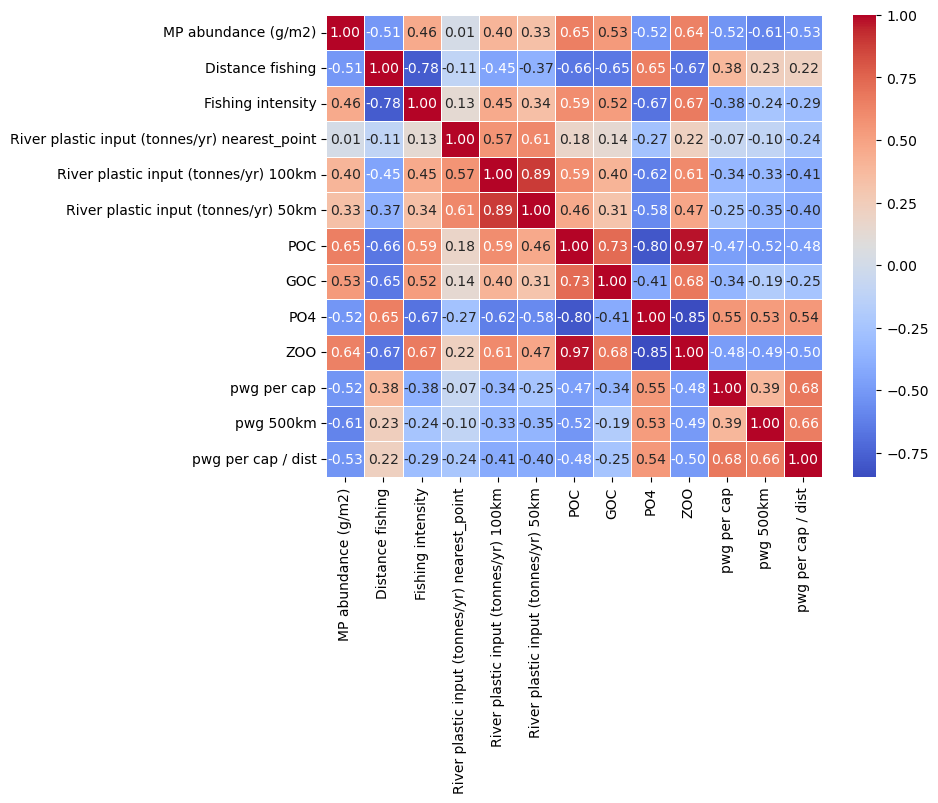

In [51]:
cols_for_matrice = ['MP abundance (g/m2)','Distance fishing',
                    'POC','GOC','Plast Float','PO4','pwg per cap','pwg 500km', 'pwg per cap / dist',]
cols_for_matrice = ['MP abundance (g/m2)', 'Sedimentation rate cm/yr',
                    'Fishing hours nearest_point',
                    'River plastic input (tonnes/yr) nearest_point',
                    'O2']

cols_for_matrice = ['MP abundance (g/m2)',
                    'Distance fishing',
                    'Fishing intensity',
                    'River plastic input (tonnes/yr) nearest_point',
                    'River plastic input (tonnes/yr) 100km',
                    'River plastic input (tonnes/yr) 50km',
                    'POC','GOC','PO4', 'ZOO',
                    'pwg per cap','pwg 500km', 'pwg per cap / dist',]



correlation_matrix = new[cols_for_matrice].corr('spearman')

print(len(correlation_matrix))

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

#plt.title('Correlation Matrix Heatmap')
plt.show()

11


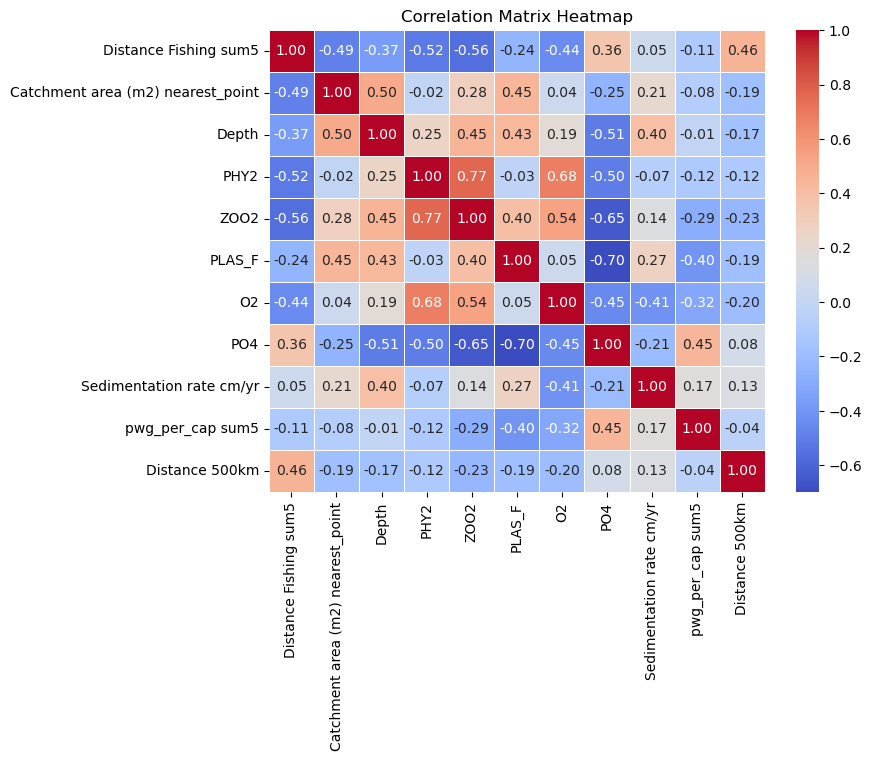

In [23]:
cols_for_matrice = data_03_frg_reduced.columns[6:].tolist()
correlation_matrix = data_03_frg_reduced[cols_for_matrice].corr('spearman')

print(len(correlation_matrix))

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

15


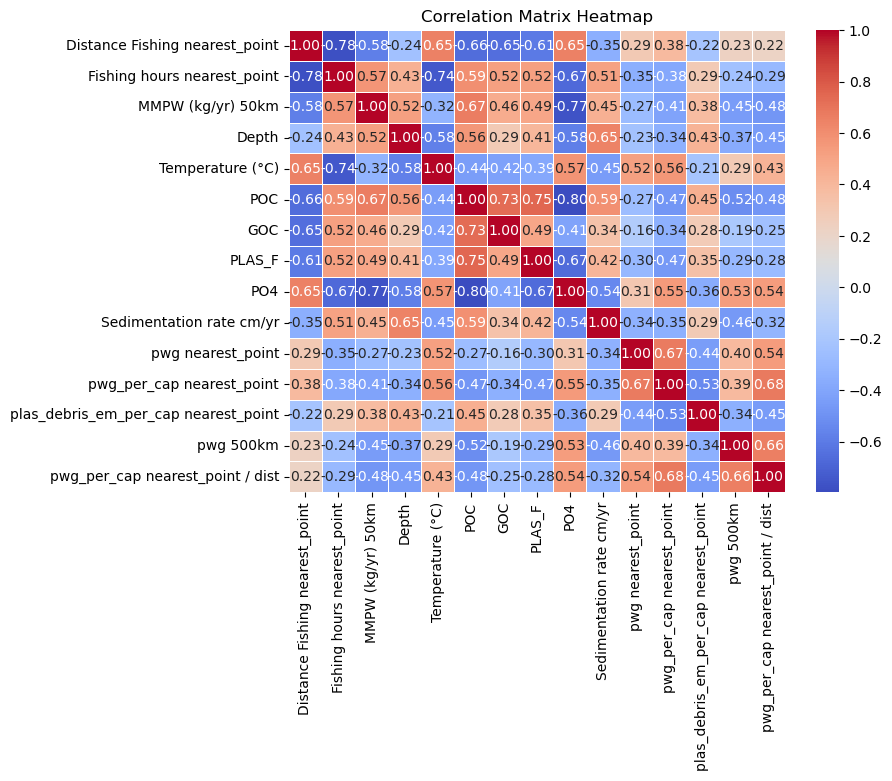

In [34]:
cols_for_matrice = data_03_fib_reduced.columns[6:].tolist()
correlation_matrix = data_03_fib_reduced[cols_for_matrice].corr('spearman')

print(len(correlation_matrix))

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

Save the new dataframes with only important parameters. They are already fit transformed!!

In [35]:
data_03_frg_reduced.to_csv('Fragment data reduced.csv', sep = ';', index = False)
data_03_fib_reduced.to_csv('Fiber data reduced.csv', sep = ';', index = False)

In [36]:
for col in data_03_fib_reduced.columns:
    na_rows = data_03_fib_reduced[data_03_fib_reduced[col].isna()].index.tolist()
    if na_rows:
        print(f"{col}: rows {na_rows}")

MP_std: rows [0, 2, 3, 4, 5, 7, 10, 11, 12, 15, 16, 18, 19, 20, 22, 23, 24, 25, 26, 28, 32, 33, 34, 36, 37, 38, 39, 42, 47, 48, 49, 52, 53, 54, 56, 57, 58, 59, 62, 64]
Temperature (°C): rows [0, 1, 2, 4, 5, 7, 10, 21, 27, 30, 32, 39, 44, 57, 60, 62]


In [37]:
for col in data_03_frg_reduced.columns:
    na_rows = data_03_frg_reduced[data_03_frg_reduced[col].isna()].index.tolist()
    if na_rows:
        print(f"{col}: rows {na_rows}")

MP_std: rows [65, 67, 68, 69, 70, 71, 73, 77, 79, 80, 83, 84, 85, 86, 87, 88, 89, 90, 92, 93, 94, 95, 98, 99, 100, 101, 102, 103]
Distance 500km: rows [69, 70, 71, 72, 73]


## Let's look at the regressions

In [25]:
spearman_df_frg

,Parameter,Spearman Correlation
0,Distance Fishing nearest_point,-0.376484
1,Distance Fishing sum5,-0.406478
2,Catchment area (m2) nearest_point,0.348528
3,Depth,0.312348
4,POC,0.392838
5,PHY,0.401964
6,ZOO,0.409846
7,PHY2,0.304273
8,ZOO2,0.430587
9,PLAS_F,0.366289


C:\Users\nelad\AppData\Local\Temp\ipykernel_15392\1661879051.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])


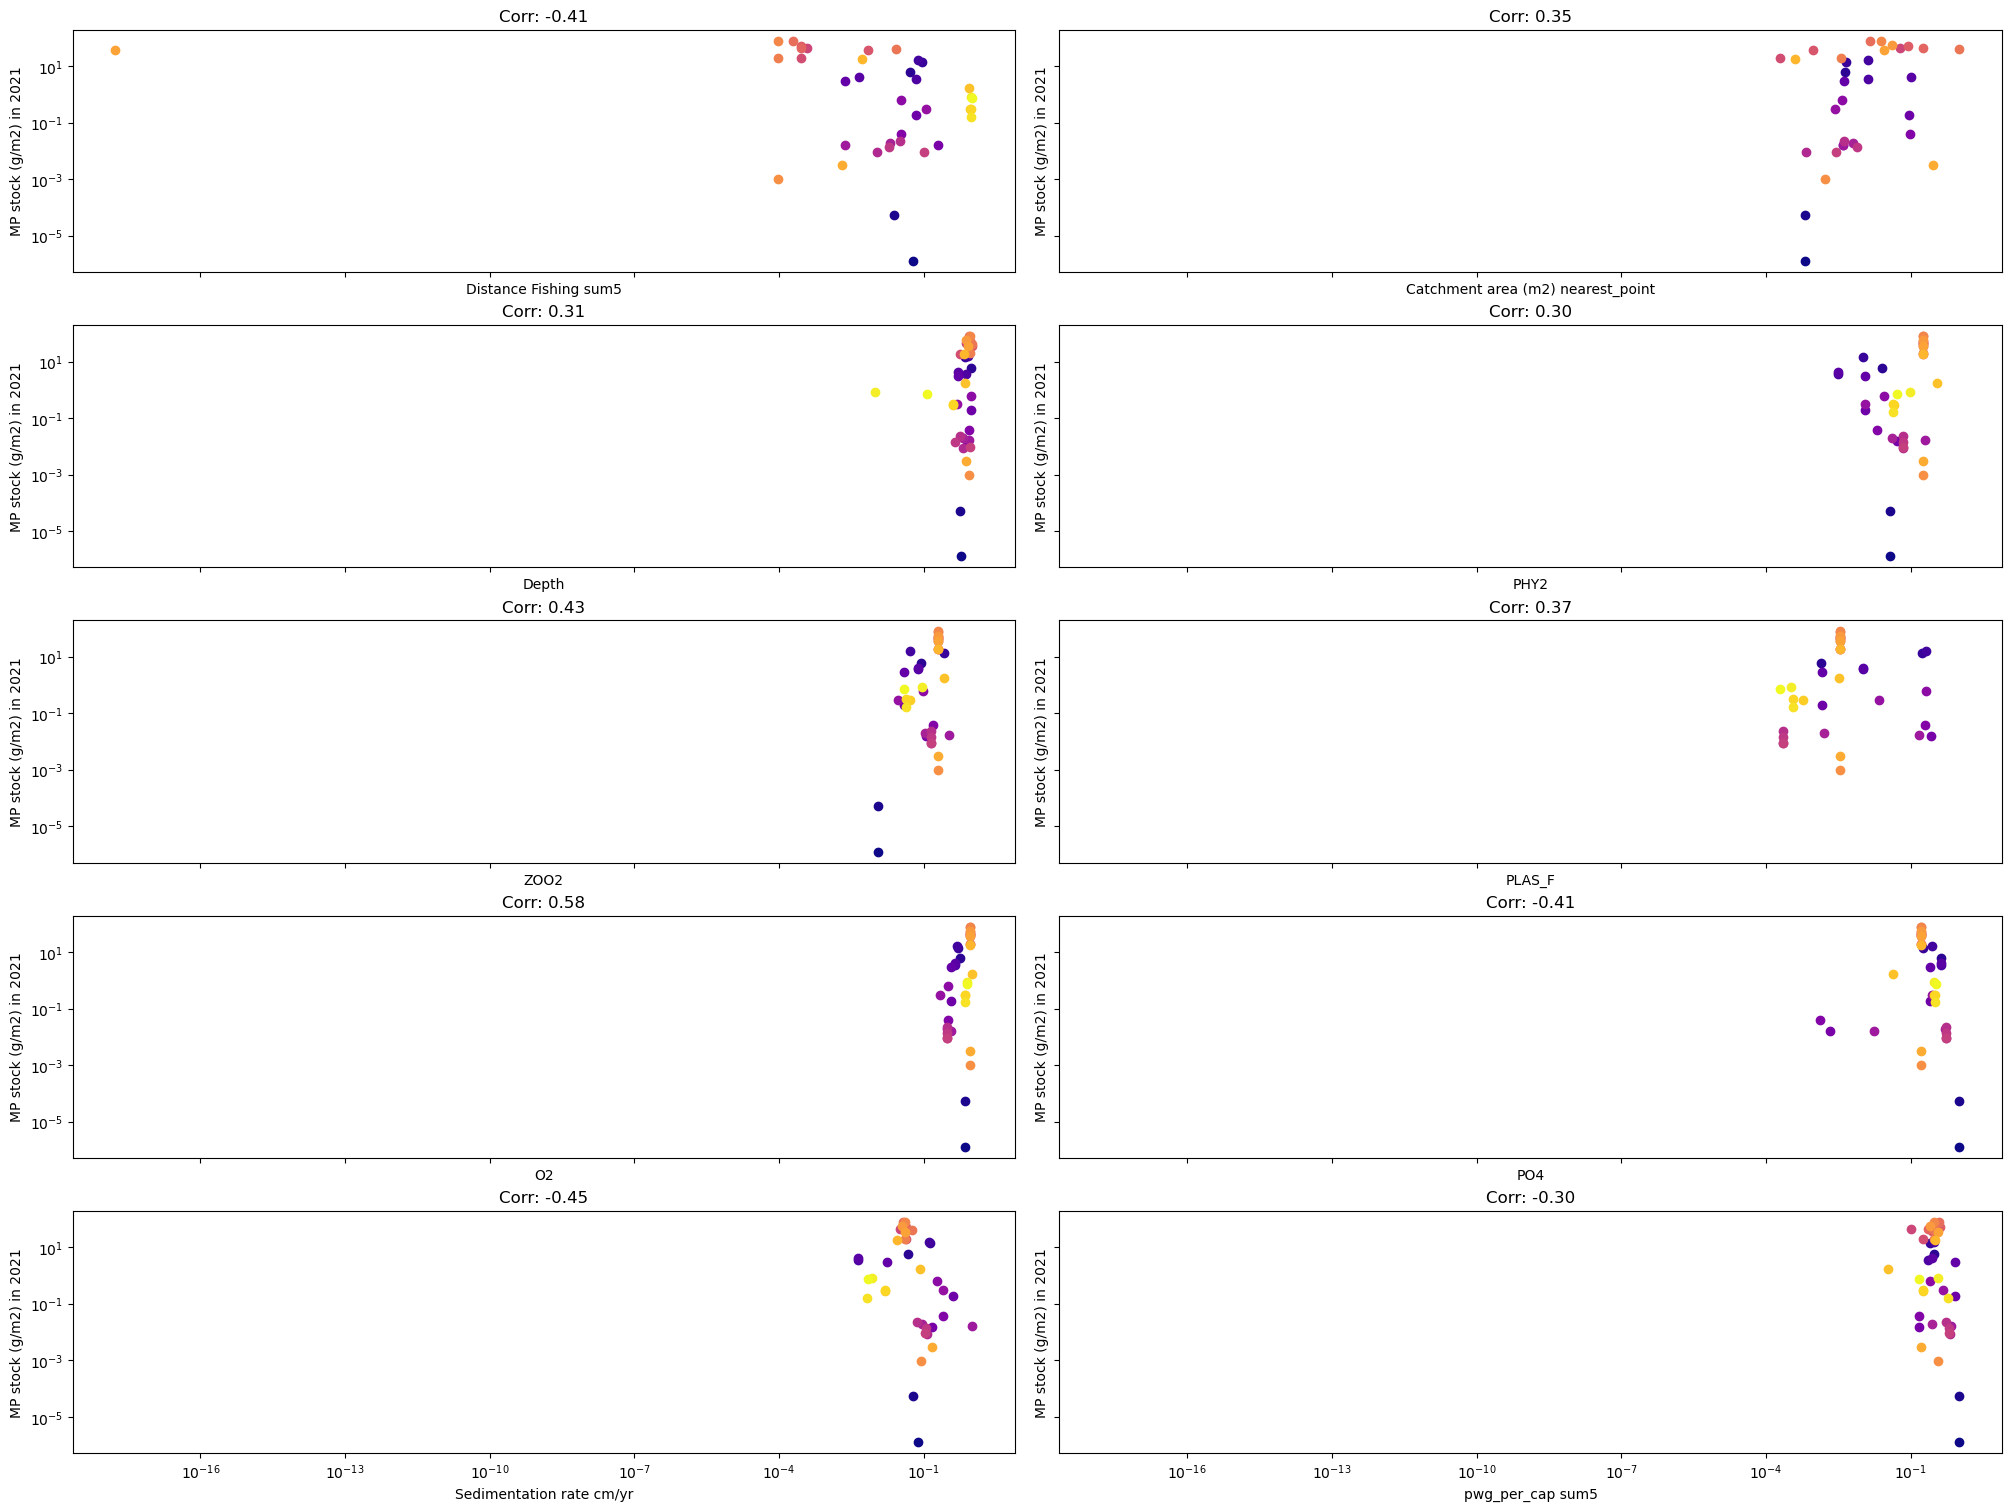

In [26]:
parameters = data_03_frg_reduced.columns[6:-1].tolist()

n = len(parameters)
if n % 2 == 0: n = n//2
else: n = n//2 + 1

cmap = plt.colormaps['plasma']
data_03_frg_reduced["Author"] = data_03_frg_reduced.index
colors = cmap(np.linspace(0, 1, len(data_03_frg_reduced["Author"].unique())))

fig, axs = plt.subplots(n, 2, sharex=True, sharey=True, layout="constrained",figsize=(20, 15))

for key in parameters:
    coef = get_spearman(key, spearman_df_frg)
    
    for i, author in enumerate(data_03_frg_reduced["Author"].unique()):
        
        subset = data_03_frg_reduced[data_03_frg_reduced["Author"] == author]
        
        axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_xlabel(key)
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_ylabel("MP stock (g/m2) in 2021")
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_title(f"Corr: {coef:.2f}")

plt.xscale("log")
plt.yscale("log")

Il faudra enlever le outlier dans le prochain notebook!

C:\Users\nelad\AppData\Local\Temp\ipykernel_15392\2232525819.py:20: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])


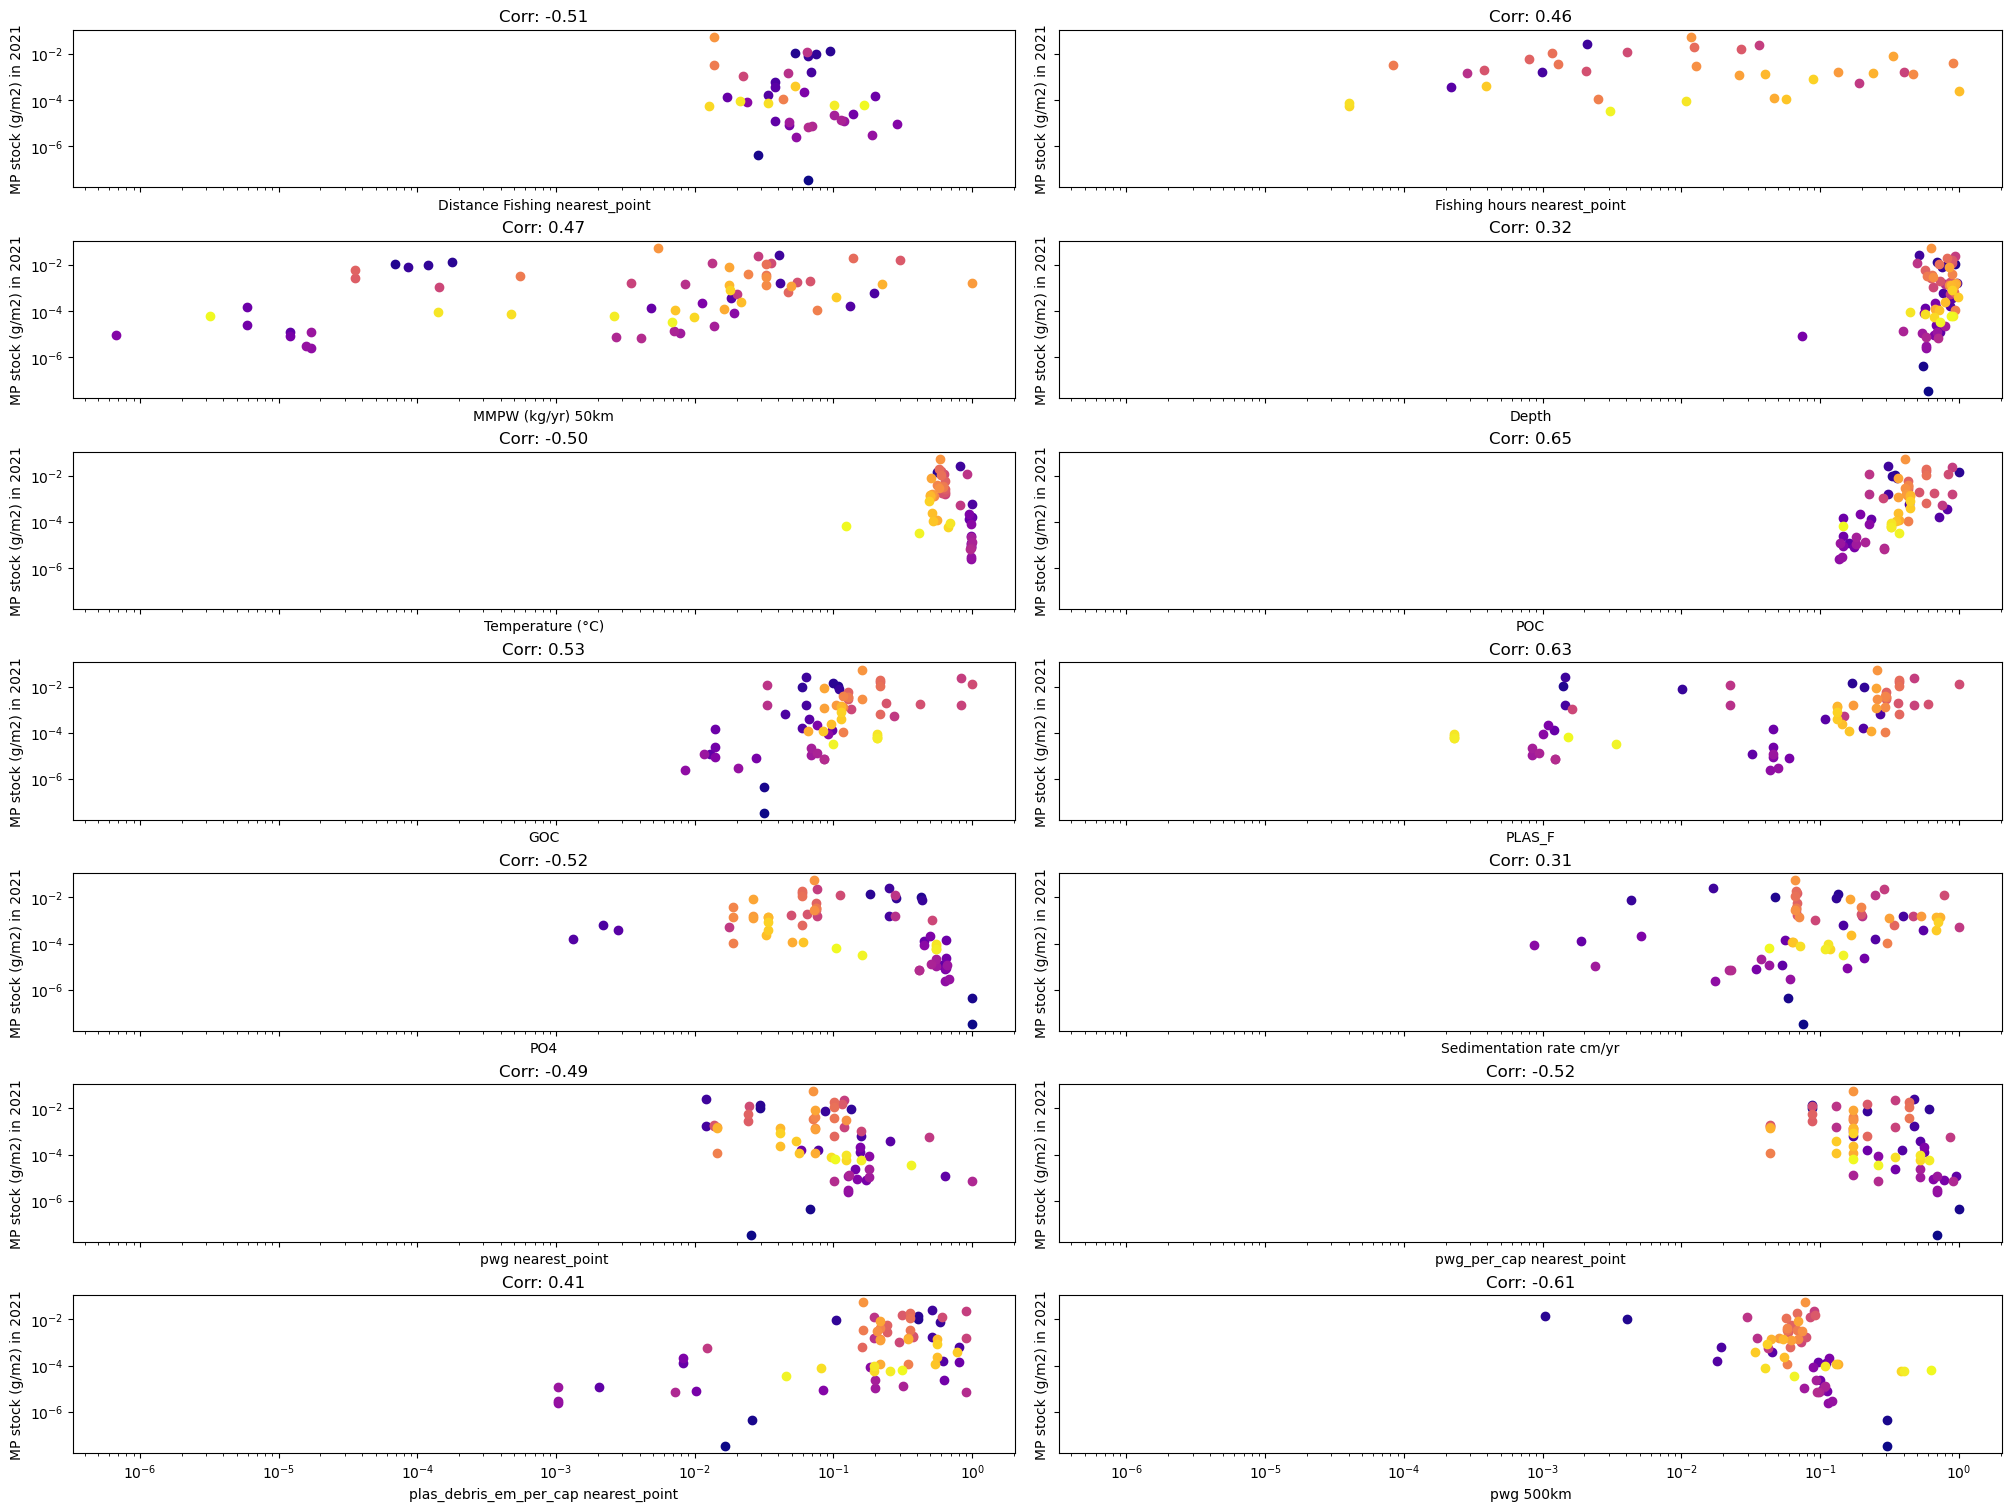

In [27]:
parameters = data_03_fib_reduced.columns[6:-1].tolist()

n = len(parameters)
if n % 2 == 0: n = n//2
else: n = n//2 + 1

cmap = plt.colormaps['plasma']
data_03_fib_reduced["Author"] = data_03_fib_reduced.index
colors = cmap(np.linspace(0, 1, len(data_03_fib_reduced["Author"].unique())))

fig, axs = plt.subplots(n, 2, sharex=True, sharey=True, layout="constrained",figsize=(20, 15))

for key in parameters:
    coef = get_spearman(key, spearman_df_fib)
    
    for i, author in enumerate(data_03_fib_reduced["Author"].unique()):
        
        subset = data_03_fib_reduced[data_03_fib_reduced["Author"] == author]
        
        axs[parameters.index(key) // 2, parameters.index(key) % 2].scatter(subset[key], subset["MEAN MP stock (g/m2) in 2021"], c=colors[i])
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_xlabel(key)
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_ylabel("MP stock (g/m2) in 2021")
        axs[parameters.index(key) // 2, parameters.index(key) % 2].set_title(f"Corr: {coef:.2f}")

plt.xscale("log")
plt.yscale("log")

## Variance

In [28]:
all_data_fib

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,uo_mean,vo_mean,Distance to land,Distance Fishing nearest_point,...,plas_em_per_cap 500km / dist,rigid_plas_deb_em 500km / dist,flex_plas_deb_em 500km / dist,rigid_plas_ob_em 500km / dist,flex_plas_ob_em 500km / dist,plas_litter_em 500km / dist,plas_uncol_em 500km / dist,plas_collection_em 500km / dist,plas_disp_em 500km / dist,plas_recy_em 500km / dist
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1.0,NaN,NaN,0.000000,0.065543,...,0.457293,0.492173,0.502898,0.728423,0.696537,0.221660,0.659974,0.227130,0.456772,0.276370
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10.0,NaN,NaN,0.000000,0.028402,...,0.458765,0.492146,0.502451,0.723901,0.691739,0.223091,0.660055,0.221514,0.447228,0.280548
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1.0,NaN,NaN,0.000000,0.052849,...,0.017019,0.008260,0.008594,0.006741,0.006890,0.005985,0.008365,0.003679,0.004015,0.010791
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1.0,0.703715,0.731527,0.052632,0.094494,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1.0,NaN,NaN,0.000000,0.075121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,Fibers,42.5,11.5,7.548057e-05,4.398004e-05,9.0,NaN,NaN,0.000000,0.033967,...,0.063499,0.033637,0.034832,0.046209,0.047340,0.033684,0.032248,0.043349,0.054035,0.037209
61,Fibers,42.5,18.5,9.272190e-05,3.968515e-05,8.0,0.573915,0.852054,0.000000,0.021106,...,0.153889,0.101490,0.103471,0.122676,0.123218,0.100023,0.100192,0.098914,0.124109,0.090358
62,Fibers,42.5,19.5,6.023320e-05,NaN,1.0,NaN,NaN,0.000000,0.101564,...,0.150221,0.109902,0.109607,0.137028,0.138025,0.127855,0.105432,0.138855,0.143767,0.095391
63,Fibers,54.5,19.5,3.372753e-05,2.108024e-05,7.0,0.717848,0.744751,0.018307,0.000000,...,0.067887,0.046100,0.045514,0.082542,0.079470,0.050529,0.052621,0.067702,0.081820,0.051062


In [29]:
parameters = all_data_fib.keys()[6:]
variances_fib = []
good_variances = []
corresponding_parameter = []
for param in parameters:
    variances_fib.append(np.var(all_data_fib[param]))


Text(0, 0.5, 'Variance')

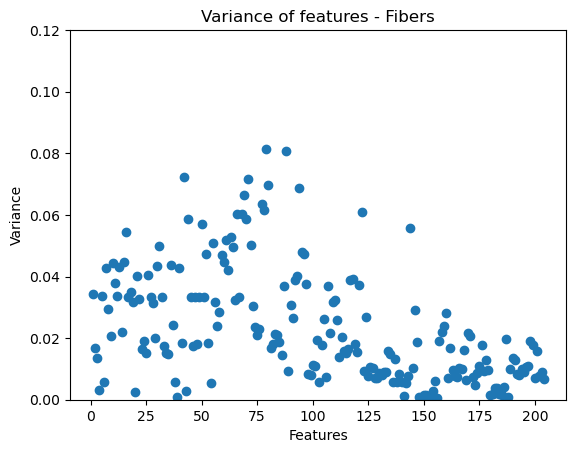

In [30]:
plt.scatter(np.arange(1,len(variances_fib)+1, 1), variances_fib)
plt.title("Variance of features - Fibers")
plt.ylim(0,0.12)
plt.xlabel("Features")
plt.ylabel("Variance")

In [31]:
parameters = all_data_fib.keys()[6:]
variances = []
good_variances = []
corresponding_parameter = []
for param in parameters:
    variances.append(np.var(all_data_fib[param]))
    if np.var(all_data_fib[param]) >= 0.05:
        good_variances.append(np.var(all_data_fib[param]))
        corresponding_parameter.append(param)
corresponding_parameter

['Mean Precipitations over 1991-2021',
 'MMPW/Area 100km',
 'MMPW/Area 50km',
 'River Input 100km',
 'Input/Distance Meijer 100km',
 'PHY',
 'PHY2',
 'NO3',
 'PLAS_C',
 'PLAS_N',
 'O2',
 'PO4',
 'Sedimentation rate cm/yr',
 'pwg_per_cap nearest_point',
 'plas_debris_em_per_cap nearest_point',
 'plas_burn_em_per_cap nearest_point',
 'plas_em_per_cap nearest_point',
 'plas_disp_em nearest_point',
 'pwg_per_cap sum5',
 'plas_disp_em 100km',
 'pwg_per_cap nearest_point / dist']

In [32]:
parameters = all_data_fib.keys()[6:]
variances = []
good_variances = []
for param in parameters:
    if np.var(all_data_fib[param]) >= 0.05:
        variance = np.var(all_data_fib[param])
        print(param, f'Variance on normalized data : {variance:.2f}' )


Mean Precipitations over 1991-2021 Variance on normalized data : 0.05
MMPW/Area 100km Variance on normalized data : 0.07
MMPW/Area 50km Variance on normalized data : 0.06
River Input 100km Variance on normalized data : 0.06
Input/Distance Meijer 100km Variance on normalized data : 0.05
PHY Variance on normalized data : 0.05
PHY2 Variance on normalized data : 0.05
NO3 Variance on normalized data : 0.06
PLAS_C Variance on normalized data : 0.06
PLAS_N Variance on normalized data : 0.07
O2 Variance on normalized data : 0.06
PO4 Variance on normalized data : 0.07
Sedimentation rate cm/yr Variance on normalized data : 0.05
pwg_per_cap nearest_point Variance on normalized data : 0.06
plas_debris_em_per_cap nearest_point Variance on normalized data : 0.06
plas_burn_em_per_cap nearest_point Variance on normalized data : 0.08
plas_em_per_cap nearest_point Variance on normalized data : 0.07
plas_disp_em nearest_point Variance on normalized data : 0.08
pwg_per_cap sum5 Variance on normalized data

## Variance FRAGMETNS

In [33]:
all_data_frg

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,uo_mean,vo_mean,Distance to land,Distance Fishing nearest_point,...,plas_em_per_cap 500km / dist,rigid_plas_deb_em 500km / dist,flex_plas_deb_em 500km / dist,rigid_plas_ob_em 500km / dist,flex_plas_ob_em 500km / dist,plas_litter_em 500km / dist,plas_uncol_em 500km / dist,plas_collection_em 500km / dist,plas_disp_em 500km / dist,plas_recy_em 500km / dist
65,Fragments,-74.5,163.5,0.000001,NaN,1.0,NaN,NaN,0.000000,0.065543,...,0.457293,0.492173,0.502898,0.728423,0.696537,0.221660,0.659974,0.227130,0.456772,0.276370
66,Fragments,-74.5,164.5,0.000053,0.000059,10.0,NaN,NaN,0.000000,0.028402,...,0.458765,0.492146,0.502451,0.723901,0.691739,0.223091,0.660055,0.221514,0.447228,0.280548
67,Fragments,-42.5,147.5,6.015802,NaN,1.0,NaN,NaN,0.000000,0.052849,...,0.017019,0.008260,0.008594,0.006741,0.006890,0.005985,0.008365,0.003679,0.004015,0.010791
68,Fragments,-38.5,144.5,14.021070,NaN,1.0,0.703715,0.731527,0.052632,0.094494,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
69,Fragments,-35.5,138.5,16.066155,NaN,1.0,NaN,NaN,0.000000,0.075121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,Fragments,-34.5,150.5,3.607515,NaN,1.0,NaN,NaN,0.000000,0.065426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,Fragments,-32.5,152.5,4.122310,NaN,1.0,0.684852,0.000000,0.011442,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72,Fragments,-23.5,-43.5,2.994523,4.007008,2.0,0.095049,0.459840,0.109840,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
73,Fragments,-22.5,-43.5,0.192126,NaN,1.0,NaN,NaN,0.000000,0.069331,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74,Fragments,-6.5,112.5,0.015863,0.007002,3.0,0.850884,0.704874,0.086957,0.037784,...,0.046618,0.055830,0.057345,0.040678,0.041269,0.048742,0.055134,0.029233,0.020443,0.055838


In [34]:
parameters = all_data_frg.keys()[6:]
variances_frg = []
good_variances = []
corresponding_parameter = []
for param in parameters:
    variances_frg.append(np.var(all_data_frg[param]))


(0.0, 0.12)

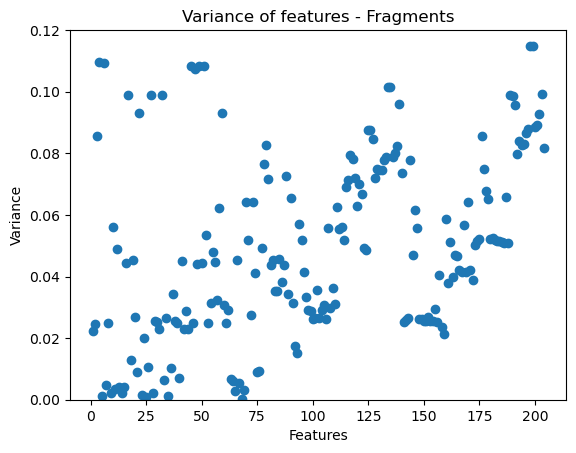

In [35]:
plt.scatter(np.arange(1,len(variances_frg)+1, 1), variances_frg)
plt.title("Variance of features - Fragments")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.ylim(0,0.12)

In [36]:
parameters = all_data_frg.keys()[6:]
variances = []
good_variances = []
corresponding_parameter = []
for param in parameters:
    variances.append(np.var(all_data_frg[param]))
    if np.var(all_data_frg[param]) >= 0.05:
        good_variances.append(np.var(all_data_frg[param]))
        corresponding_parameter.append(param)
corresponding_parameter

['Distance to land',
 'Distance Fishing nearest_point',
 'Distance Fishing sum5',
 'Distance Fishing 50km',
 'Distance Lebreton nearest_point',
 'Distance Lebreton sum5',
 'Distance Lebreton 100km',
 'Distance Lebreton 50km',
 'Distance Meijer nearest_point',
 'Distance Meijer sum5',
 'Distance Meijer 100km',
 'Distance Meijer 50km',
 'River Input 50km',
 'Depth',
 'Temperature (°C)',
 'O2',
 'PO4',
 'Distance nearest_point',
 'plas_debris_em_per_cap nearest_point',
 'plas_burn_em_per_cap nearest_point',
 'plas_em_per_cap nearest_point',
 'plas_disp_em nearest_point',
 'Distance sum5',
 'pwg_per_cap sum5',
 'plas_debris_em_per_cap sum5',
 'Distance 100km',
 'pwg_per_cap 100km',
 'plas_debris_em_per_cap 100km',
 'plas_burn_em_per_cap 100km',
 'plas_em_per_cap 100km',
 'rigid_plas_deb_em 100km',
 'flex_plas_deb_em 100km',
 'rigid_plas_ob_em 100km',
 'flex_plas_ob_em 100km',
 'plas_litter_em 100km',
 'plas_uncol_em 100km',
 'plas_collection_em 100km',
 'plas_disp_em 100km',
 'Population_2

In [37]:
parameters = all_data_frg.keys()[6:]
variances = []
good_variances = []
for param in parameters:
    if np.var(all_data_frg[param]) >= 0.05:
        variance = np.var(all_data_frg[param])
        print(param, f'Variance on normalized data : {variance:.2f}' )


Distance to land Variance on normalized data : 0.09
Distance Fishing nearest_point Variance on normalized data : 0.11
Distance Fishing sum5 Variance on normalized data : 0.11
Distance Fishing 50km Variance on normalized data : 0.06
Distance Lebreton nearest_point Variance on normalized data : 0.10
Distance Lebreton sum5 Variance on normalized data : 0.09
Distance Lebreton 100km Variance on normalized data : 0.10
Distance Lebreton 50km Variance on normalized data : 0.10
Distance Meijer nearest_point Variance on normalized data : 0.11
Distance Meijer sum5 Variance on normalized data : 0.11
Distance Meijer 100km Variance on normalized data : 0.11
Distance Meijer 50km Variance on normalized data : 0.11
River Input 50km Variance on normalized data : 0.05
Depth Variance on normalized data : 0.06
Temperature (°C) Variance on normalized data : 0.09
O2 Variance on normalized data : 0.06
PO4 Variance on normalized data : 0.05
Distance nearest_point Variance on normalized data : 0.06
plas_debris_

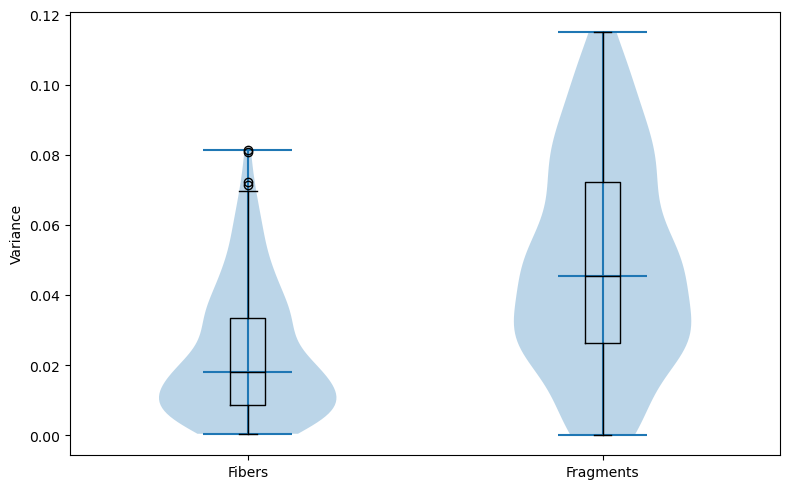

In [38]:
fig, ax = plt.subplots(figsize=(8, 5))

# Violin + boxplot
ax.violinplot([variances_fib, variances_frg], positions=[1, 2], showmedians=True)
ax.boxplot([variances_fib, variances_frg], positions=[1, 2], widths=0.1,
           patch_artist=False, medianprops=dict(color='black'))



ax.set_xticks([1, 2])
ax.set_xticklabels(['Fibers', 'Fragments'])
ax.set_ylabel('Variance')
plt.tight_layout()
plt.show()

## Selection of parameters for clustering

Parameters are selected based on high correlation coefficient and high variance. Only around 10 parameters for each shape make it to for the clustering. The datasets created in this section are not used in the final clustering. It is used for preliminary tests, clustering only on data with associated concentrations.

In [39]:
selected_fibers = ['Distance Fishing nearest_point',
'Mean Precipitations over 1991-2021' ,
'MMPW/Area 100km',
'POC' ,
'PO4' ,
'PLAS_F', 
'Sedimentation rate cm/yr' ,
'River Input 100km',
'pwg_per_cap nearest_point / dist',
]

In [40]:
selected_fragments = ['uo_mean' ,
'Sedimentation rate cm/yr' ,
'Distance to land' ,
'Distance Fishing nearest_point',
'Distance Meijer nearest_point' ,
'River Input 50km' ,
'Depth' ,
'O2' ,
'PLAS_F' ,
'pwg_per_cap nearest_point / dist',
'Population_2020 500km / dist' ]

## New dataframes

In [41]:
selected_data_fib = all_data_fib[[
'Shape',	'Lat_center',	'Lon_center',	'MEAN MP stock (g/m2) in 2021',	'MP_std',	'n_points',	
*selected_fibers,]]

selected_data_frg = all_data_frg[[
'Shape',	'Lat_center',	'Lon_center',	'MEAN MP stock (g/m2) in 2021',	'MP_std',	'n_points',	
*selected_fragments ]]

In [42]:
selected_data_frg.to_csv('Fragments parameters for clustering.csv', index = False)
selected_data_fib.to_csv('Fibers parameters for clustering.csv', index = False)